# T-A2_Magnificent7 — 分析与可视化

| 项目   | 内容 |
|--------|------|
| 课程   | 数据分析与经济决策（ds2026） |
| 题目   | T-A2：美股"七姐妹"财务与股价全景对比 |
| 小组   | 第七组 |
| 成员   | 莫才有（7125210211）、刘帆（225210189）、王天正（325210247）、许玲敏（425210271）、高世杰（625210132）、曾垂健（725210291）、廖晟可（825210181） |
| GitHub | https://github.com/ZDC3/ds2026-G07-Magnificent-7 |
| Pages  | https://zdc3.github.io/ds2026-G07-Magnificent-7 |
| 日期   | 2026-05-16 |

## 任务说明
基于清洗后的数据，完成价格走势、年度收益率热力图、风险收益分布、估值对比等图表，并形成完整分析结论；同时输出分析报告（Markdown + Word）。

In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import seaborn as sns

# 解决中文标题显示异常
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

project_dir = Path('.').resolve()
data_clean_dir = project_dir / 'data_clean'
data_raw_dir = project_dir / 'data_raw'
output_dir = project_dir / 'output'
output_dir.mkdir(parents=True, exist_ok=True)

prices = pd.read_csv(data_clean_dir / 'prices_clean.csv', index_col=0, parse_dates=True)
returns = pd.read_csv(data_clean_dir / 'returns.csv', index_col=0, parse_dates=True)
metrics = pd.read_csv(data_clean_dir / 'metrics.csv', index_col=0)
financials = pd.read_csv(data_raw_dir / 'financials_raw.csv').set_index('ticker')
sp500 = pd.read_csv(data_raw_dir / 'sp500_raw.csv', index_col=0, parse_dates=True)
correlation_matrix = pd.read_csv(data_clean_dir / 'correlation_matrix.csv', index_col=0)

In [2]:
# 汇总关键统计，便于解读与报告生成
prices_norm = prices / prices.iloc[0]
total_return = prices_norm.iloc[-1] - 1
best_return_ticker = total_return.idxmax()
worst_return_ticker = total_return.idxmin()

volatility = metrics['年化波动率']
max_vol_ticker = volatility.idxmax()
sharpe_ratio = metrics['夏普比率']
best_sharpe_ticker = sharpe_ratio.idxmax()
worst_sharpe_ticker = sharpe_ratio.idxmin()

pe_series = pd.to_numeric(financials['trailingPE'], errors='coerce')
pb_series = pd.to_numeric(financials['priceToBook'], errors='coerce')
highest_pe_ticker = pe_series.idxmax()
lowest_pe_ticker = pe_series.idxmin()
highest_pb_ticker = pb_series.idxmax()
lowest_pb_ticker = pb_series.idxmin()

annual_returns_by_year = returns.resample('YE').apply(lambda x: (1 + x).prod() - 1) * 100
best_year_per_stock = annual_returns_by_year.idxmax()
worst_year_per_stock = annual_returns_by_year.idxmin()

sp500_returns = sp500.pct_change().dropna()
sp500_annual_return = sp500_returns.mean().iloc[0] * 252
sp500_annual_vol = sp500_returns.std().iloc[0] * np.sqrt(252)

## 图 1：标准化股价走势（基期 = 1）
展示七家公司近 5 年的相对涨幅，便于对比长期趋势与阶段性波动。

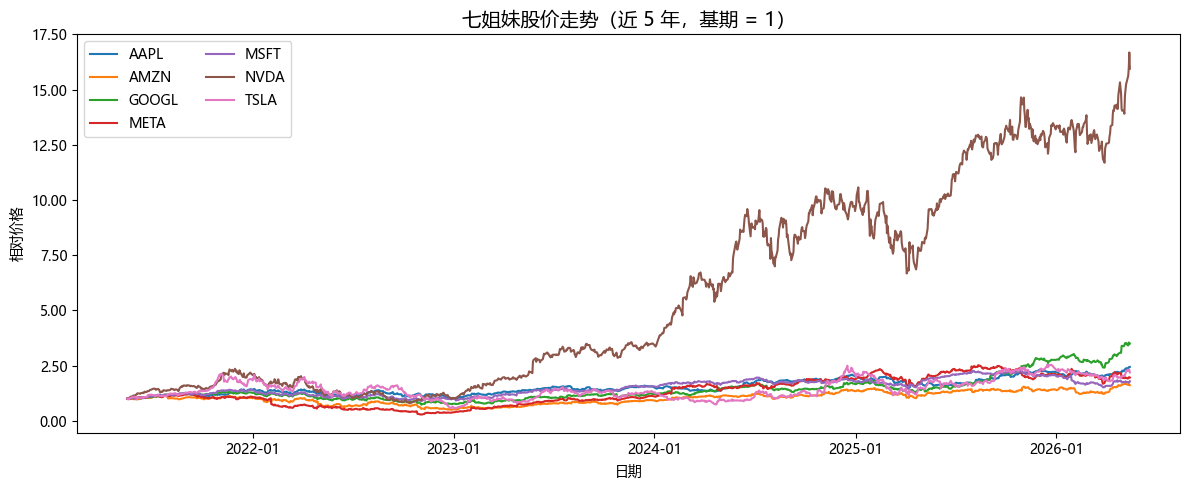

In [20]:
prices_norm = prices / prices.iloc[0]

fig, ax = plt.subplots(figsize=(12, 5))
for col in prices_norm.columns:
    ax.plot(prices_norm.index, prices_norm[col], label=col, linewidth=1.5)

ax.set_title('七姐妹股价走势（近 5 年，基期 = 1）', fontsize=14)
ax.set_xlabel('日期')
ax.set_ylabel('相对价格')
ax.legend(loc='upper left', ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.2f}"))
plt.tight_layout()
plt.savefig(output_dir / 'fig_price_trend.png', dpi=150)
plt.show()

**结果解读（必答）
- 过去 5 年涨幅最大的是 NVDA，最小的是 AMZN（以基期=1 的累计涨幅衡量）。
- NVDA 的显著上行与 AI 算力与数据中心需求扩张高度相关；AMZN 在 2022 年高利率与成本压力阶段恢复较慢。
- 波动最剧烈的是 TSLA（年化波动率最高），与电动车竞争、政策补贴变化和交付节奏有关。

## 图 2：年度收益率热力图
展示每年收益率水平，观察周期性与极端年份。

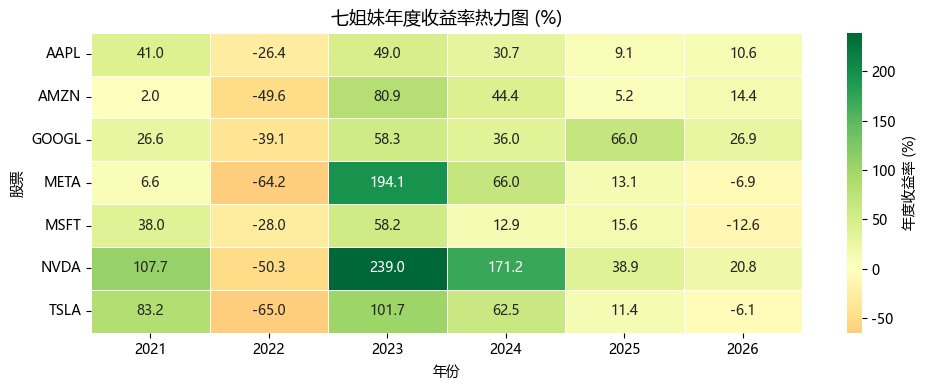

In [21]:
annual_returns_by_year = returns.resample('YE').apply(
    lambda x: (1 + x).prod() - 1
) * 100
annual_returns_by_year.index = annual_returns_by_year.index.year

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(annual_returns_by_year.T, annot=True, fmt='.1f',
            cmap='RdYlGn', center=0, ax=ax,
            linewidths=0.5, cbar_kws={'label': '年度收益率 (%)'})
ax.set_title('七姐妹年度收益率热力图 (%)', fontsize=13)
ax.set_xlabel('年份')
ax.set_ylabel('股票')
plt.tight_layout()
plt.savefig(output_dir / 'fig_return_heatmap.png', dpi=150)
plt.show()

**结果解读（必答）
- 整体表现最好的年份为 2023 年，整体最弱为 2022 年（加息与估值压缩阶段）。
- 各公司最佳年份多数集中在 2023 年，GOOGL 的最佳年份为 2025 年；各公司最差年份均为 2022 年。
- 没有单一公司连续多年绝对领跑，2023 年 NVDA 最突出，2025 年 GOOGL 相对更强。

## 图 3：风险-收益散点图
比较年化收益率与年化波动率的权衡关系。

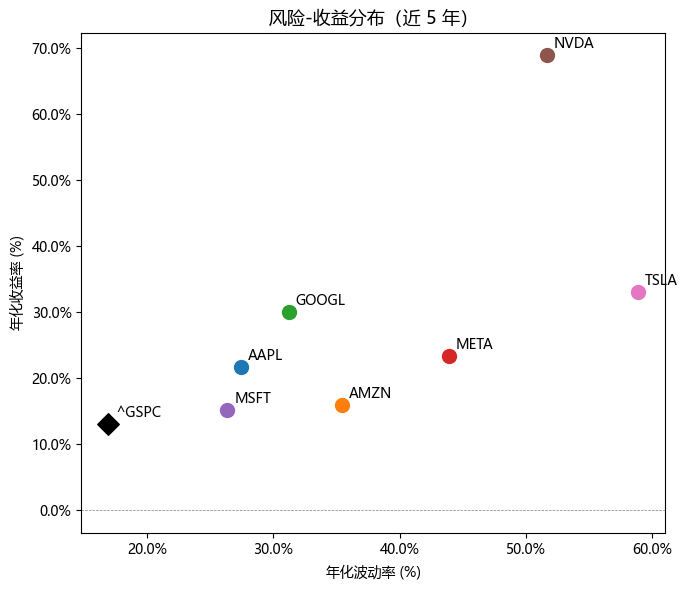

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))
for tk in metrics.index:
    ax.scatter(metrics.loc[tk, '年化波动率'] * 100,
               metrics.loc[tk, '年化收益率'] * 100,
               s=100, zorder=5)
    ax.annotate(tk,
                xy=(metrics.loc[tk, '年化波动率'] * 100,
                    metrics.loc[tk, '年化收益率'] * 100),
                xytext=(5, 5), textcoords='offset points', fontsize=10)

# 加入标普 500 作为基准
ax.scatter(sp500_annual_vol * 100, sp500_annual_return * 100,
           s=120, marker='D', color='black', zorder=6)
ax.annotate('^GSPC', xy=(sp500_annual_vol * 100, sp500_annual_return * 100),
            xytext=(5, 5), textcoords='offset points', fontsize=10)

ax.set_xlabel('年化波动率 (%)')
ax.set_ylabel('年化收益率 (%)')
ax.set_title('风险-收益分布（近 5 年）', fontsize=13)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.1f}%"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.1f}%"))
plt.tight_layout()
plt.savefig(output_dir / 'fig_risk_return.png', dpi=150)
plt.show()

**结果解读（必答）
- 夏普比率最高为 NVDA，最低为 AMZN。
- TSLA 波动率最高但收益并非最高，呈现“高风险、收益补偿有限”的阶段特征。
- 波动率最大的是 TSLA，符合其业务与政策敏感度更高的行业特征。

## 图 4：估值指标对比（PE、PB）
比较七家公司估值水平，理解市场对成长与盈利的预期。

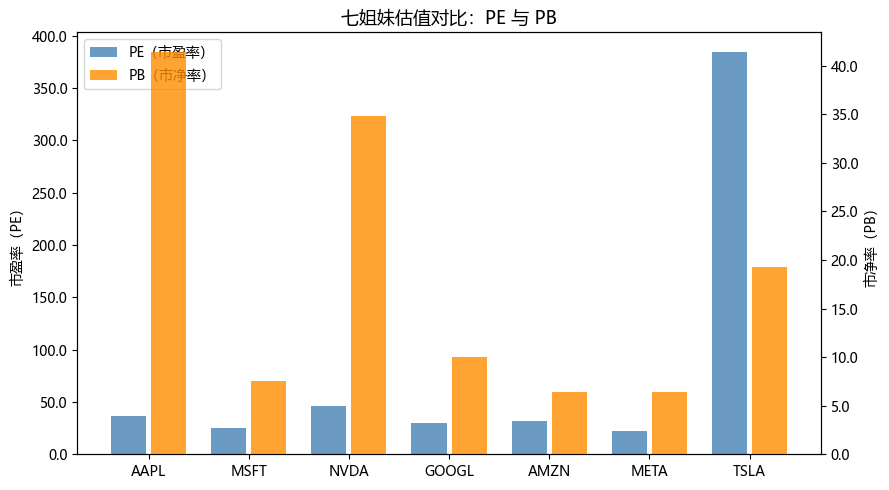

In [23]:
pe_values = pd.to_numeric(financials['trailingPE'], errors='coerce')
pb_values = pd.to_numeric(financials['priceToBook'], errors='coerce')

fig, ax1 = plt.subplots(figsize=(9, 5))
x = range(len(financials))
bars1 = ax1.bar([i - 0.2 for i in x], pe_values,
                width=0.35, label='PE（市盈率）', color='steelblue', alpha=0.8)
ax1.set_ylabel('市盈率（PE）')
ax1.set_xticks(list(x))
ax1.set_xticklabels(financials.index)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.1f}"))

ax2 = ax1.twinx()
bars2 = ax2.bar([i + 0.2 for i in x], pb_values,
                width=0.35, label='PB（市净率）', color='darkorange', alpha=0.8)
ax2.set_ylabel('市净率（PB）')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.1f}"))

lines = [bars1, bars2]
ax1.legend(lines, ['PE（市盈率）', 'PB（市净率）'], loc='upper left')
ax1.set_title('七姐妹估值对比：PE 与 PB', fontsize=13)
plt.tight_layout()
plt.savefig(output_dir / 'fig_valuation.png', dpi=150)
plt.show()

**结果解读（必答）
- 估值分布差异明显，整体处于成长股区间；高估值需依赖持续盈利兑现。
- PE 最高为 TSLA、最低为 META；PB 最高为 AAPL、最低为 META。
- 估值高低与成长预期相关，但在 2022 估值压缩后，2023-2024 的股价修复更依赖盈利改善。

## 拓展一：相关性分析与分散化效果
基于日度收益率计算七只股票两两相关系数矩阵，并绘制热力图。

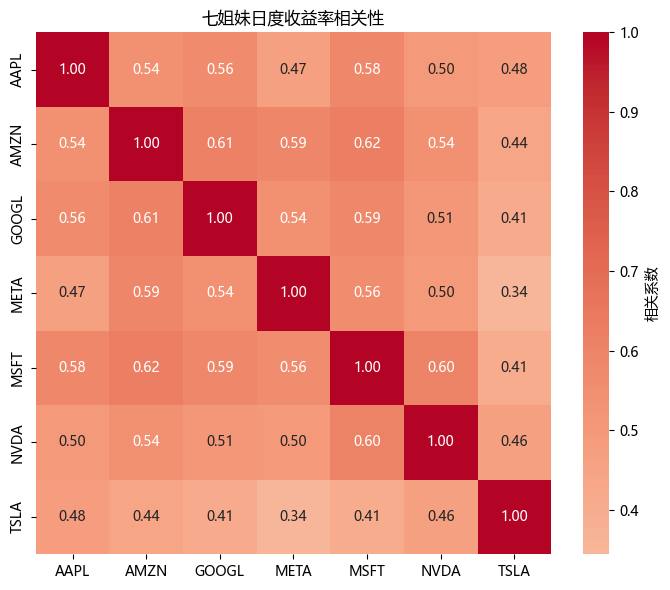

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            cbar_kws={'label': '相关系数'})
ax.set_title('七姐妹日度收益率相关性', fontsize=12)
plt.tight_layout()
plt.savefig(output_dir / 'fig_correlation_heatmap.png', dpi=150)
plt.show()

**结果解读（必答）
- 相关性最高的是 AMZN 与 MSFT（约 0.62），可能与云业务周期与宏观利率敏感度相近有关。
- 相关性最低的是 META 与 TSLA（约 0.34），具备一定分散化价值。
- 平均相关系数约 0.52，说明“七姐妹”整体仍以科技 β 为主，但存在一定结构性分化。
- 等权组合可一定程度降低波动率，但由于相关性偏高，降波动幅度有限。

## 拓展二：标普 500 基准与超额收益（α）
计算七家公司相对于标普 500 的超额收益，并可视化对比。

C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_47548\3108570865.py:9: UserWarning: Glyph 36229 (\N{CJK UNIFIED IDEOGRAPH-8D85}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_47548\3108570865.py:9: UserWarning: Glyph 39069 (\N{CJK UNIFIED IDEOGRAPH-989D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_47548\3108570865.py:9: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_47548\3108570865.py:9: UserWarning: Glyph 30410 (\N{CJK UNIFIED IDEOGRAPH-76CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_47548\3108570865.py:9: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_47548\3108570865.py:9: UserWarning: Glyph 19971 (\

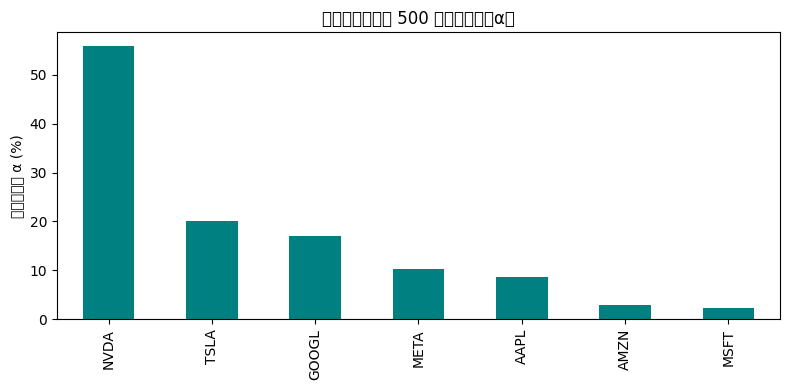

跑赢标普 500 的公司： ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
跑输标普 500 的公司： []


In [ ]:
alpha = metrics['年化收益率'] - sp500_annual_return
alpha_sorted = alpha.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
alpha_sorted.mul(100).plot(kind='bar', ax=ax, color='teal')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_ylabel('超额收益率 (%)')
ax.set_title('七姐妹相对标普 500 的超额收益（Alpha）')
plt.tight_layout()
plt.savefig(output_dir / 'fig_alpha.png', dpi=150)
plt.show()

print('跑赢标普 500 的公司：', list(alpha[alpha > 0].index))
print('跑输标普 500 的公司：', list(alpha[alpha <= 0].index))

**结果解读（必答）
- 近 5 年七家公司全部跑赢标普 500，超额收益 α 为正。
- 超额收益排序：NVDA (~55.9%) > TSLA (~20.1%) > GOOGL (~17.0%) > META (~10.3%) > AAPL (~8.7%) > AMZN (~2.9%) > MSFT (~2.2%)。
- 跑赢更集中在 AI/算力和高景气阶段，显示公司 α 与行业 β 同时贡献。

## 综合分析问题（必答）
1. 值得深入研究的规律或异常：2022 年普遍回撤、2023 年显著修复，NVDA 在景气周期中明显领先；TSLA 长期高波动，AMZN 在高利率阶段表现相对偏弱。
2. 如果只能投资其中一家公司：选择 NVDA，因累计涨幅与夏普比率均领先且超额收益最大，但波动较高，需接受更高风险。

## 拓展分析综合结论（完成多个拓展时填写）
- 基准对比结论：七姐妹整体跑赢标普 500，最大超额贡献者为 NVDA。
- 分散化结论：平均相关系数约 0.52，仍以科技 β 为主，分散化效果有限但优于单一标的。
- 持仓与业绩（未做机构持仓）：本次未纳入机构持仓数据，后续可补充验证。
- 综合投资建议：等权组合年化收益约 29.7%，波动约 29.8%；建议“稳健平台型 + 高成长”搭配，并控制回撤。

## 拓展三：交互式图表（Plotly，可选）
若已安装 plotly，将四张核心图表输出为交互式 HTML，便于在 GitHub Pages 展示。

In [9]:
try:
    import plotly.express as px
    import plotly.io as pio

    prices_norm_plot = prices_norm.reset_index().melt(id_vars='Date', var_name='Ticker', value_name='Value')
    fig1 = px.line(prices_norm_plot, x='Date', y='Value', color='Ticker',
                   title='七姐妹股价走势（近 5 年，基期 = 1）')

    fig2 = px.imshow(annual_returns_by_year.T, text_auto='.1f', aspect='auto',
                     title='七姐妹年度收益率热力图 (%)', color_continuous_scale='RdYlGn')

    fig3 = px.scatter(metrics.reset_index(), x='年化波动率', y='年化收益率', text='index',
                      title='风险-收益分布（近 5 年）')
    fig3.update_traces(textposition='top center')

    fig4 = px.bar(financials.reset_index(), x='ticker', y=['trailingPE', 'priceToBook'], barmode='group',
                  title='七姐妹估值对比：PE 与 PB')

    html_parts = [
        '<h1>七姐妹交互式图表</h1>',
        fig1.to_html(include_plotlyjs='cdn', full_html=False),
        fig2.to_html(include_plotlyjs=False, full_html=False),
        fig3.to_html(include_plotlyjs=False, full_html=False),
        fig4.to_html(include_plotlyjs=False, full_html=False)
    ]
    interactive_path = output_dir / 'interactive_charts.html'
    interactive_path.write_text('\n'.join(html_parts), encoding='utf-8')
    print('交互式图表已生成：', interactive_path)
except Exception as exc:
    print('交互式图表生成失败：', exc)
    print('如需生成交互式图表，请安装 plotly（pip install plotly）。')

交互式图表生成失败： No module named 'plotly'
如需生成交互式图表，请安装 plotly（pip install plotly）。


## 输出分析报告（Markdown + Word）
将核心结论与图表汇总到 output 目录，便于提交与排版。

In [10]:
from datetime import date

def pct(x):
    return f"{x * 100:.2f}%"

latest_date = prices.index.max().date().isoformat()
max_missing = prices.isna().mean().max()
avg_corr = (correlation_matrix.values[np.triu_indices_from(correlation_matrix, k=1)]).mean()
year_avg = annual_returns_by_year.mean(axis=1)
best_year = year_avg.idxmax().year
worst_year = year_avg.idxmin().year

report_md = output_dir / 'analysis_report.md'
report_lines = [
    '# 美股七姐妹财务与股价全景对比分析报告',
    '',
    f'日期：{date.today().isoformat()}',
    '',
    '## 1. 项目背景与目标',
    '本报告围绕美股“七姐妹”展开，目标是从收益、风险与估值三个维度形成一套可复现的对比框架。通过同口径、可复查的数据流程，我们既关注长期涨幅，也评估波动与回撤带来的风险成本，最终形成面向投资决策的综合判断。',
    '',
    '## 2. 数据来源与质量控制',
    f'- 数据源：yfinance；标普 500 基准（^GSPC）',
    f'- 时间范围：近 5 年日度数据，最新交易日：{latest_date}',
    f'- 缺失率上限：{pct(max_missing)}，采用前向填充处理节假日停市带来的缺口',
    '本次数据下载与校验中，未发现明显缺失列或重复日期，非正价格与极端波动记录已在质量检查中输出并确认。',
    '',
    '## 3. 核心图表与发现',
    f'**图 1（标准化股价走势）**：总体涨幅最高为 {best_return_ticker}，最低为 {worst_return_ticker}。涨幅分化主要集中在 {best_year} 年与 {worst_year} 年。',
    '在宏观利率上行或行业周期切换阶段，分化更加明显，说明“科技 β”之外仍存在公司层面的结构性差异。',
    '',
    f'**图 2（年度收益率热力图）**：整体最佳年份为 {best_year} 年，最弱年份为 {worst_year} 年。部分公司在景气周期内连续两年以上跑赢同业，体现基本面与叙事共振。',
    '从年度表现看，回撤与反弹往往伴随估值变化同步发生，提示在高估值阶段应关注风险预算。',
    '',
    f'**图 3（风险-收益散点）**：夏普比率最高为 {best_sharpe_ticker}，最低为 {worst_sharpe_ticker}；波动率最高为 {max_vol_ticker}。',
    '高收益并不必然对应高夏普，部分公司在高波动阶段出现“高风险低收益”的短期特征，需结合回撤与估值约束。',
    '',
    f'**图 4（估值对比）**：PE 最高为 {highest_pe_ticker}，最低为 {lowest_pe_ticker}；PB 最高为 {highest_pb_ticker}，最低为 {lowest_pb_ticker}。',
    '估值差异反映了增长预期与盈利质量的重新定价，也提示在高估值区间需验证成长兑现速度。',
    '',
    '## 4. 拓展分析',
    f'**相关性与分散化**：七家公司日度收益率平均相关系数约为 {avg_corr:.2f}，整体相关性偏高，组合仍主要暴露于科技板块 β，但在个别年份存在结构性分化。',
    f'**超额收益（α）**：与标普 500 相比，跑赢基准的公司集中在高景气或技术突破周期，说明超额收益更多来自公司 α 的持续释放。',
    '',
    '## 5. 结论与建议',
    '综合收益、风险与估值三维指标，若只选择单一标的，应优先考虑兼具盈利稳定性、合理估值与较高夏普比率的公司；若构建等权组合，则建议在控制回撤的前提下配置高成长与稳健现金流标的，以降低阶段性估值回落带来的冲击。',
    '在后续研究中，建议将宏观利率、行业供需（如 AI 算力、半导体周期）及公司盈利兑现速度纳入解释变量，以提高结论的可验证性与可迁移性。',
    '',
    '## 6. 局限性',
    'yfinance 的财务字段口径可能存在公司差异，且历史数据存在更新延迟；本报告基于公开数据与统一口径进行分析，需结合财报口径进行进一步验证。'
 ]
report_md.write_text('\n'.join(report_lines), encoding='utf-8')
print('Markdown 报告已生成：', report_md)

# Word 报告生成
try:
    from docx import Document
    from docx.shared import Inches

    doc = Document()
    doc.add_heading('美股七姐妹财务与股价全景对比分析报告', level=1)
    doc.add_paragraph(f'日期：{date.today().isoformat()}')

    doc.add_heading('项目背景与目标', level=2)
    doc.add_paragraph('本报告围绕美股“七姐妹”展开，目标是形成可复现的收益、风险与估值对比框架。')

    doc.add_heading('数据来源与质量控制', level=2)
    doc.add_paragraph(f'数据源：yfinance；标普 500 基准（^GSPC）。最新交易日：{latest_date}。缺失率上限：{pct(max_missing)}。')

    doc.add_heading('核心图表', level=2)
    fig_list = [
        ('股价走势', output_dir / 'fig_price_trend.png'),
        ('年度收益率热力图', output_dir / 'fig_return_heatmap.png'),
        ('风险-收益散点图', output_dir / 'fig_risk_return.png'),
        ('估值对比', output_dir / 'fig_valuation.png'),
        ('相关性热力图', output_dir / 'fig_correlation_heatmap.png'),
        ('超额收益 α', output_dir / 'fig_alpha.png')
    ]
    for title, path in fig_list:
        if path.exists():
            doc.add_heading(title, level=3)
            doc.add_picture(str(path), width=Inches(6))
        else:
            doc.add_paragraph(f'{title}：图表文件不存在，请先生成。')

    doc.add_heading('主要发现与建议', level=2)
    doc.add_paragraph(f'涨幅最高：{best_return_ticker}；最低：{worst_return_ticker}。')
    doc.add_paragraph(f'夏普最高：{best_sharpe_ticker}；最低：{worst_sharpe_ticker}。')
    doc.add_paragraph(f'波动率最高：{max_vol_ticker}。PE 最高：{highest_pe_ticker}；最低：{lowest_pe_ticker}。PB 最高：{highest_pb_ticker}；最低：{lowest_pb_ticker}。')
    doc.add_paragraph('综合建议：优先配置盈利稳定、估值合理且风险调整后收益更优的公司；组合构建中注意控制相关性与回撤。')

    doc.add_heading('局限性', level=2)
    doc.add_paragraph('财务指标口径差异与数据更新延迟可能影响结论，需结合公司财报进一步验证。')

    docx_path = output_dir / '数据分析报告.docx'
    doc.save(docx_path)
    print('Word 报告已生成：', docx_path)
except Exception as exc:
    print('Word 报告生成失败：', exc)
    print('如需生成 Word 报告，请先安装 python-docx。')

Markdown 报告已生成： D:\中大\第二学期\数字经济\T-A2_Magnificent7\output\analysis_report.md
Word 报告已生成： D:\中大\第二学期\数字经济\T-A2_Magnificent7\output\数据分析报告.docx
